In [1]:
# conda activate anndata

import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
# Load cell metadata and latent space
adata = ad.read_h5ad("data/yao_2021_ACA_MOp_VISp_STAR_model/yao_2021_ACA_MOp_VISp_STAR_gene_counts_scVI.h5ad")

# Load single-cell PSI data
sdata = ad.read_h5ad("data/yao_2021_ACA_MOp_VISp_STAR_SJ_counts_PSI_annotated.h5ad")

In [3]:
sum(~(adata.obs_names == sdata.obs_names))

0

In [4]:
adata.obs.value_counts("subclass_label")



subclass_label
L4/5 IT CTX        3544
L6 CT CTX          3425
Vip                2446
L6 IT CTX          2353
Pvalb              1820
L2/3 IT CTX        1779
Sst                1725
L5 IT CTX          1579
Lamp5              1396
L6b CTX            1169
L5/6 NP CTX         882
L5 PT CTX           498
Sncg                331
Astro               215
L2/3 IT PPP         143
Sst Chodl           100
Oligo                97
Endo                 69
SMC-Peri             49
Micro-PVM            46
Car3                 42
VLMC                 42
Meis2                38
L5/6 IT TPE-ENT       8
CR                    4
L4 RSP-ACA            1
Name: count, dtype: int64

## Choose data source

In [5]:
# data_source = "yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules_Claude_marker_genes_enrichments_ctype_abundance_PSI_vs_exon_corr"
# corr_df = pd.read_csv(f"data/corrs/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules_Claude_marker_genes_enrichments_ctype_abundance_PSI_vs_exon_corr.csv", index_col=0)

In [6]:
data_source = "yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules_yao_2021_ACA_MOp_VISp_STAR_donor_subclass_label_pseudobulk_pairwise_DE_genes_strictFALSE_logFC3_nSignif21_enrichments_PSI_vs_exon_corr"
corr_df = pd.read_csv(f"data/corrs/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules_yao_2021_ACA_MOp_VISp_STAR_donor_subclass_label_pseudobulk_pairwise_DE_genes_strictFALSE_logFC3_nSignif21_enrichments_PSI_vs_exon_corr.csv", index_col=0)

In [7]:
ctypes = corr_df.columns[1:]
gene_names_df = corr_df['Gene']

In [8]:
ctypes

Index(['Pvalb', 'L2_3_IT_CTX', 'L6b_CTX', 'Lamp5', 'L5_PT_CTX', 'Sncg',
       'L5_6_NP_CTX', 'Sst_Chodl', 'Meis2', 'Oligo', 'Car3', 'VLMC',
       'SMC-Peri', 'Astro', 'Endo', 'Micro-PVM'],
      dtype='object')

## Prep UMAP

In [9]:
sc.pp.neighbors(adata, use_rep="scVI")
sc.tl.umap(adata, min_dist=0.3)

/mnt/lareaulab/reliscu/anaconda3/envs/anndata/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
all_ctypes = [
    'CR', 'Car3', 'L2/3 IT CTX', 'L2/3 IT PPP',
    'L4/5 IT CTX', 'L4 RSP-ACA', 'L5/6 IT TPE-ENT', 'L5/6 NP CTX',
    'L5 IT CTX', 'L5 PT CTX', 'L6 CT CTX', 'L6 IT CTX', 'L6b CTX',
    'Pvalb', 'Sst', 'Sst Chodl', 'Lamp5', 'Sncg', 'Vip', 'Meis2', 
    'Astro', 'Oligo', 'Endo', 'SMC-Peri', 'VLMC', 'Micro-PVM'
    ]

In [11]:
# Step 1: order the base label
adata.obs["subclass_label"] = pd.Categorical(
    adata.obs["subclass_label"],
    categories=all_ctypes,
    ordered=True,
)

# Step 2: build plot_label (it will inherit the categorical order)
counts = adata.obs["subclass_label"].value_counts()
plot_label_order = [f"{ct} (n={counts[ct]:,})" for ct in all_ctypes]

adata.obs["plot_label"] = adata.obs["subclass_label"].apply(
    lambda ct: f"{ct} (n={counts[ct]:,})"
)
adata.obs["plot_label"] = pd.Categorical(
    adata.obs["plot_label"],
    categories=plot_label_order,
    ordered=True,
)

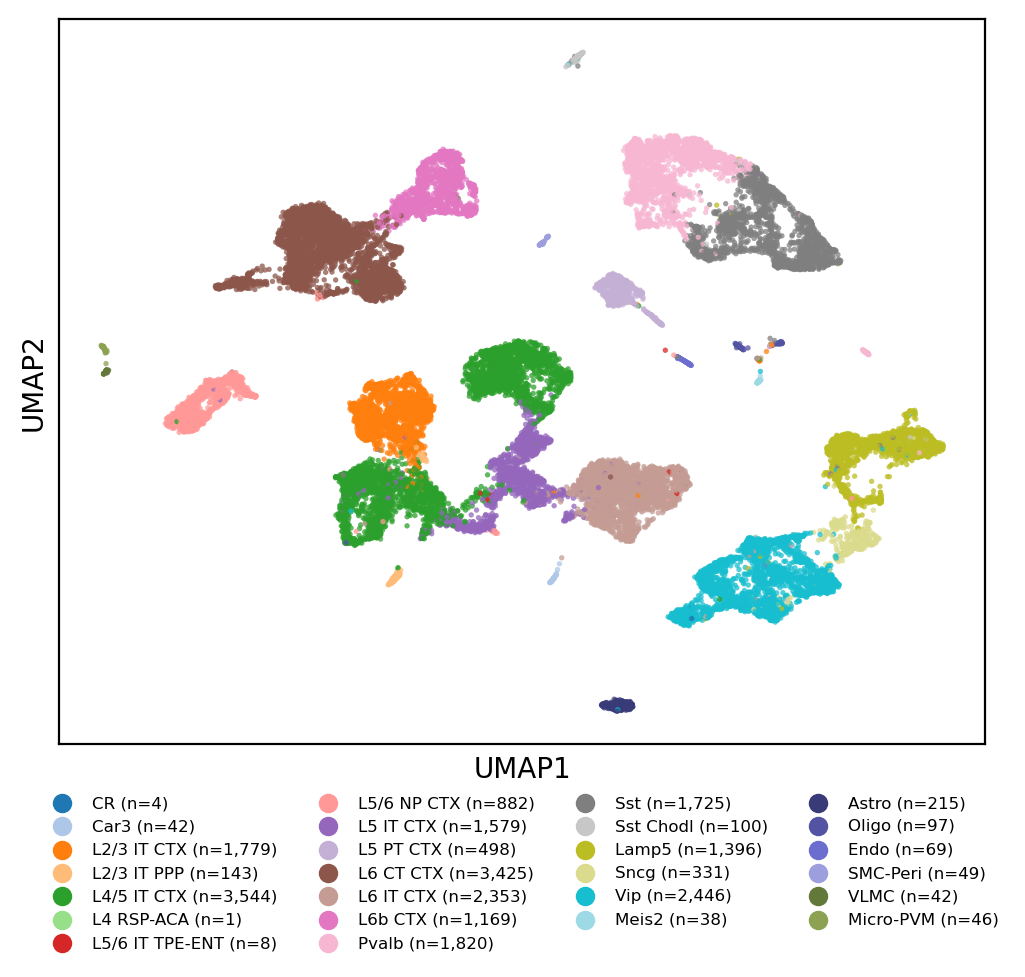

In [12]:
import scanpy as sc

fig, ax = plt.subplots(figsize=(5.5, 5), dpi=200)

palette = (
    list(plt.get_cmap("tab20").colors) +
    list(plt.get_cmap("tab20b").colors)
)[:len(all_ctypes)]

sc.pl.umap(adata, title="", color="plot_label", size=15, alpha=.75, ax=ax, show=False,
           palette=palette)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05),
          ncol=4, fontsize=6, frameon=False)
plt.tight_layout()
plt.show()

## Add PSIs to metadata

In [13]:
psi_df = pd.DataFrame(
    sdata.X, index=sdata.obs_names, columns=sdata.var_names
)

adata_psi = adata.copy()
adata_psi.obs = adata_psi.obs.join(psi_df)

## Plot

In [14]:
outdir = f"figures/scRNA-seq/{data_source}"

In [19]:
top_n = 15
ascending = False 

In [ ]:
os.makedirs(outdir, exist_ok=True)

def _safe(name):
    import re
    # simple filename sanitizer
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(name))

for ctype in ctypes:
    print(ctype)
    top_genes = corr_df.sort_values(ctype, ascending=ascending)[:top_n]
    pdf_path = f"{outdir}/{_safe(ctype)}_top{top_n}_ascending{ascending}.pdf"
    with PdfPages(pdf_path) as pdf:
        for idx, row in top_genes.iterrows():
            gene = row['Gene']
            exon = "_".join(row.name.split("_")[-2:])
            exon_len = sdata.var.loc[row.name]['exon_end'] - sdata.var.loc[row.name]['exon_start'] + 1

            fig, axs = plt.subplots(3, 1, figsize=(8, 15), dpi=200)
            
            sc.pl.umap(adata_psi, title="",
                    color="subclass_label", size=10,
                    ax=axs[0], show=False, use_raw=True)

            sc.pl.umap(adata_psi, title=f"{ctype} eigengene vs. PSI corr: {np.round(row[ctype], 3)}\n{gene} {exon}\nExon length: {exon_len}",
                    color=row.name, size=10,
                    ax=axs[1], show=False, use_raw=True)

            sc.pl.umap(adata_psi, title=f"{gene} expression",
                    color=row['Gene'], size=10,
                    ax=axs[2], show=False, use_raw=True)

            for a in axs:
                a.legend(loc="center left", bbox_to_anchor=(1.0, 0.5),
                        ncol=1, fontsize=8, frameon=False)

            fig.set_dpi(125)
            plt.tight_layout()
            pdf.savefig(fig, bbox_inches='tight')
            # plt.show()
            plt.close(fig)

Pvalb


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

L2_3_IT_CTX


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

L6b_CTX


...

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

Oligo


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

Car3


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 